<a href="https://colab.research.google.com/github/kritikagg/E-Commerce_Demand_Inventory_Analytics/blob/main/E_Commerce_Demand_Inventory_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tools:** Python | SQL Server | Power BI

## Project Objective
Analyze e-commerce demand patterns, forecast product demand,
and identify inventory risks using Python, SQL, and Power BI.

#1. Dataset Generation

**Setup**

In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

**Product master (hierarchy + demand tier)**

In [ ]:
categories = {
    "Electronics": ["Audio", "Mobile Accessories", "Wearables"],
    "Home & Kitchen": ["Cookware", "Storage", "Small Appliances"],
    "Fashion": ["Men's Apparel", "Women's Apparel", "Footwear"],
    "Beauty": ["Skincare", "Haircare"],
    "Sports": ["Fitness Equipment", "Outdoor Gear"],
}

product_rows = []
pid = 1000
for cat, subs in categories.items():
    for i in range(10):  # 10 products per category -> 50 total
        sub = subs[i % len(subs)]
        tier = rng.choice(["fast", "medium", "slow"], p=[0.25, 0.5, 0.25])
        base_price = round(rng.uniform(200, 8000), 2)
        product_rows.append({
            "ProductID": f"P{pid}",
            "ProductName": f"{cat[:3].upper()}-{sub[:3].upper()}-{pid}",
            "Category": cat,
            "SubCategory": sub,
            "SupplierID": f"S{rng.integers(1, 16)}",
            "DemandTier": tier,
            "BasePrice": base_price,
            "LeadTimeDays": int(rng.integers(3, 21)),
        })
        pid += 1

products = pd.DataFrame(product_rows)
products.head()

,ProductID,ProductName,Category,SubCategory,SupplierID,DemandTier,BasePrice,LeadTimeDays
0,P1000,ELE-AUD-1000,Electronics,Audio,S7,slow,3623.25,18
1,P1001,ELE-MOB-1001,Electronics,Mobile Accessories,S8,medium,934.58,20
2,P1002,ELE-WEA-1002,Electronics,Wearables,S8,slow,6331.30,5
3,P1003,ELE-AUD-1003,Electronics,Audio,S3,medium,3092.22,19
4,P1004,ELE-MOB-1004,Electronics,Mobile Accessories,S9,medium,6617.54,10


**Date range + seasonality/region setup**

In [ ]:
start = pd.Timestamp("2024-04-01")
end = pd.Timestamp("2025-09-30")
dates = pd.date_range(start, end, freq="D")

def seasonality(date):
    month = date.month
    if month in (10, 11, 12):
        return 1.5   # festive season
    if month in (6, 7):
        return 0.85  # summer dip
    if month == 1:
        return 1.15  # new year bump
    return 1.0

tier_base = {"fast": 8, "medium": 3, "slow": 1}
regions = ["North", "South", "East", "West", "Central"]
region_weight = [0.28, 0.24, 0.18, 0.20, 0.10]

n_customers = 6000
customer_ids = [f"C{i}" for i in range(1, n_customers + 1)]

**Transaction generation loop**

In [ ]:
rows = []
order_id = 1
for date in dates:
    season = seasonality(date)
    dow_factor = 1.2 if date.dayofweek in (5, 6) else 1.0

    spike_product = None
    if rng.random() < 0.03:
        spike_product = products.sample(1).iloc[0]["ProductID"]

    n_orders_today = int(rng.poisson(150) * season * dow_factor)
    for _ in range(n_orders_today):
        prod = products.sample(1).iloc[0]
        lam = tier_base[prod["DemandTier"]] * season
        if spike_product is not None and prod["ProductID"] == spike_product:
            lam *= 4

        qty = max(1, int(rng.poisson(lam)))
        discount = float(rng.choice([0, 0, 0, 0.05, 0.10, 0.15, 0.20],
                                     p=[0.45, 0.1, 0.1, 0.15, 0.1, 0.06, 0.04]))
        qty = max(1, int(round(qty * (1 + discount * 0.8))))
        unit_price = round(prod["BasePrice"] * rng.uniform(0.95, 1.05), 2)

        rows.append({
            "OrderID": f"O{order_id}",
            "OrderDate": date,
            "ProductID": prod["ProductID"],
            "ProductName": prod["ProductName"],
            "Category": prod["Category"],
            "SubCategory": prod["SubCategory"],
            "Quantity": qty,
            "UnitPrice": unit_price,
            "Discount": discount,
            "CustomerID": rng.choice(customer_ids),
            "Region": rng.choice(regions, p=region_weight),
            "InventoryAtStart": int(rng.integers(20, 500)),
            "ReorderPoint": int(rng.integers(15, 80)),
            "LeadTimeDays": prod["LeadTimeDays"],
            "SupplierID": prod["SupplierID"],
        })
        order_id += 1

df = pd.DataFrame(rows)
df.shape

(91361, 15)

**Intentionally introduce dirtiness (for cleaning stage)**

In [ ]:
dirty = df.copy()

# missing values
mask = rng.random(len(dirty)) < 0.02
dirty.loc[mask, "Discount"] = np.nan
mask2 = rng.random(len(dirty)) < 0.01
dirty.loc[mask2, "CustomerID"] = np.nan

# inconsistent text casing
case_mask = rng.random(len(dirty)) < 0.05
dirty.loc[case_mask, "Region"] = dirty.loc[case_mask, "Region"].str.upper()

# duplicate rows
dupes = dirty.sample(frac=0.005, random_state=1)
dirty = pd.concat([dirty, dupes], ignore_index=True)

# a few bad values
bad_idx = dirty.sample(20, random_state=2).index
dirty.loc[bad_idx[:10], "Quantity"] = -1
dirty.loc[bad_idx[10:], "UnitPrice"] = 0

dirty.shape

(91818, 15)

**Save files**

In [ ]:
dirty.to_csv("ecommerce_raw.csv", index=False)
products.drop(columns=["DemandTier"]).to_csv("product_master.csv", index=False)  # optional reference

**Validation**

In [ ]:
print("Rows:", len(dirty))
print("Date range:", dirty["OrderDate"].min(), "to", dirty["OrderDate"].max())
print("Unique products:", dirty["ProductID"].nunique())
print("Unique customers:", dirty["CustomerID"].nunique(dropna=True))
print("\nMissing values:\n", dirty.isna().sum()[dirty.isna().sum() > 0])
print("\nDuplicate rows:", dirty.duplicated().sum())
print("\nRevenue summary:")
print((dirty["Quantity"] * dirty["UnitPrice"]).describe())
print("\nQuantity summary:")
print(dirty["Quantity"].describe())

Rows: 91818
Date range: 2024-04-01 00:00:00 to 2025-09-30 00:00:00
Unique products: 50
Unique customers: 6000

Missing values:
 Discount      1831
CustomerID     926
dtype: int64

Duplicate rows: 455

Revenue summary:
count     91818.000000
mean      17164.908320
std       20270.575213
min       -7565.530000
25%        4502.032500
50%        9259.220000
75%       21548.055000
max      274724.080000
dtype: float64

Quantity summary:
count    91818.000000
mean         4.163584
std          3.416365
min         -1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         68.000000
Name: Quantity, dtype: float64


#2. Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_raw.csv")
df.shape

(91818, 15)

**Deduplicate + handle missing values**

In [ ]:
before = len(df)
df = df.drop_duplicates()
print("Removed duplicates:", before - len(df))

df["Discount"] = df["Discount"].fillna(0)
df["CustomerID"] = df["CustomerID"].fillna("UNKNOWN")

Removed duplicates: 455


**Datatype conversion + text standardization**

In [ ]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["Region"] = df["Region"].str.title()
df["Category"] = df["Category"].str.title()

**Invalid value checks**

In [ ]:
before = len(df)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
print("Removed invalid rows:", before - len(df))

Removed invalid rows: 20


**Outlier inspection (visual only, no removal — real e-commerce data has legitimate large orders)**

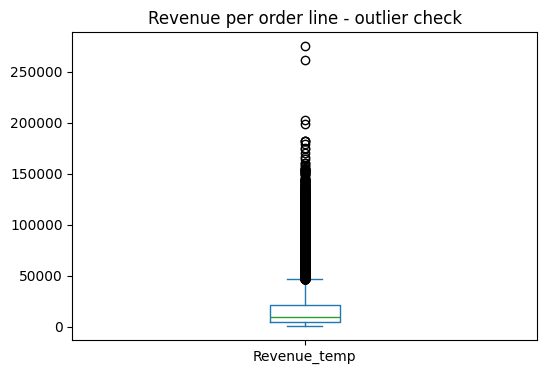

In [ ]:
df["Revenue_temp"] = df["Quantity"] * df["UnitPrice"]
df["Revenue_temp"].describe()
plt.figure(figsize=(6,4))
df["Revenue_temp"].plot(kind="box")
plt.title("Revenue per order line - outlier check")
plt.show()
df = df.drop(columns=["Revenue_temp"])

**Derived financial columns**

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df["DiscountAmount"] = df["Revenue"] * df["Discount"]
df["NetRevenue"] = df["Revenue"] - df["DiscountAmount"]
df["Cost"] = df["UnitPrice"] * 0.6 * df["Quantity"]   # assumed 60% COGS ratio
df["Profit"] = df["NetRevenue"] - df["Cost"]
df["ProfitMargin"] = df["Profit"] / df["NetRevenue"]

**Date features**

In [ ]:
df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month
df["MonthName"] = df["OrderDate"].dt.strftime("%b")
df["Week"] = df["OrderDate"].dt.isocalendar().week
df["DayOfWeek"] = df["OrderDate"].dt.day_name()
df["Quarter"] = df["OrderDate"].dt.quarter

**Save cleaned dataset**

In [ ]:
df.to_csv("ecommerce_clean.csv", index=False)
df.shape

(91343, 27)

#3. EDA (Business Questions)

**Q1/Q2: Top products by revenue and by quantity**

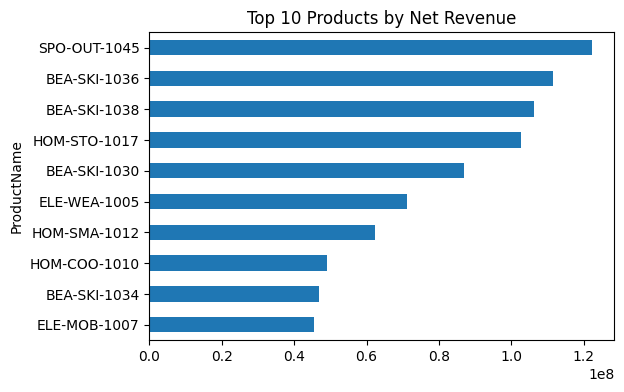

,Quantity
ProductName,
ELE-AUD-1009,16915
HOM-STO-1017,16840
BEA-HAI-1037,16711
FAS-FOO-1028,16626
HOM-SMA-1012,16578
SPO-OUT-1045,16537
ELE-WEA-1005,16294
BEA-SKI-1030,16011
BEA-SKI-1038,15969


In [ ]:
top_rev = df.groupby("ProductName")["NetRevenue"].sum().sort_values(ascending=False).head(10)
top_qty = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)
top_rev.plot(kind="barh", figsize=(6,4), title="Top 10 Products by Net Revenue"); plt.gca().invert_yaxis(); plt.show()
top_qty

**Q3: Category growth (first half vs second half of period)**

In [ ]:
mid = df["OrderDate"].median()
early = df[df["OrderDate"] <= mid].groupby("Category")["NetRevenue"].sum()
late = df[df["OrderDate"] > mid].groupby("Category")["NetRevenue"].sum()
growth = ((late - early) / early * 100).sort_values(ascending=False)
growth

,NetRevenue
Category,
Sports,-8.769336
Fashion,-12.826780
Electronics,-12.907147
Home & Kitchen,-14.093942
Beauty,-14.525432


**Q4/Q5: Monthly demand pattern + seasonality**

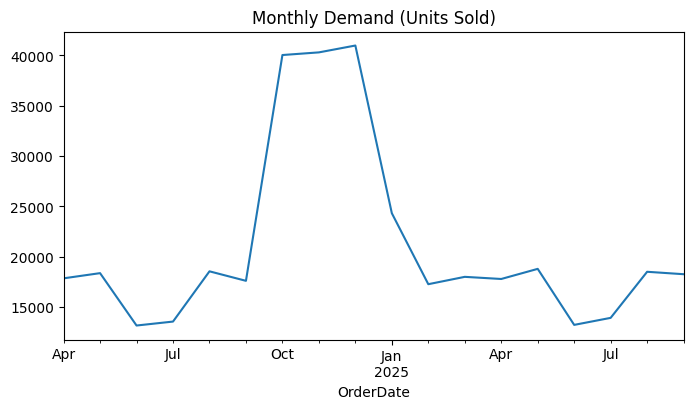

In [ ]:
monthly = df.groupby(df["OrderDate"].dt.to_period("M"))["Quantity"].sum()
monthly.plot(figsize=(8,4), title="Monthly Demand (Units Sold)"); plt.show()

**Q6: Slow-moving products (bottom 10 by quantity)**

In [ ]:
slow = df.groupby("ProductName")["Quantity"].sum().sort_values().head(10)
slow

,Quantity
ProductName,
FAS-WOM-1021,2548
BEA-HAI-1033,2602
SPO-FIT-1046,2614
FAS-WOM-1024,2616
ELE-WEA-1002,2650
ELE-AUD-1000,2670
ELE-AUD-1006,2677
HOM-SMA-1015,2695
ELE-WEA-1008,2712


**Q7: Volatile-demand products (highest coefficient of variation)**

In [ ]:
monthly_product = df.groupby(["ProductName", df["OrderDate"].dt.to_period("M")])["Quantity"].sum().unstack(fill_value=0)
cv = (monthly_product.std(axis=1) / monthly_product.mean(axis=1)).sort_values(ascending=False)
cv.head(10)

,0
ProductName,
HOM-COO-1010,0.547008
FAS-MEN-1029,0.523897
BEA-SKI-1034,0.508730
BEA-HAI-1037,0.505153
SPO-FIT-1040,0.504734
SPO-OUT-1045,0.501427
FAS-FOO-1028,0.488603
BEA-HAI-1031,0.486535
ELE-AUD-1003,0.486378


**Q8: Regional revenue**

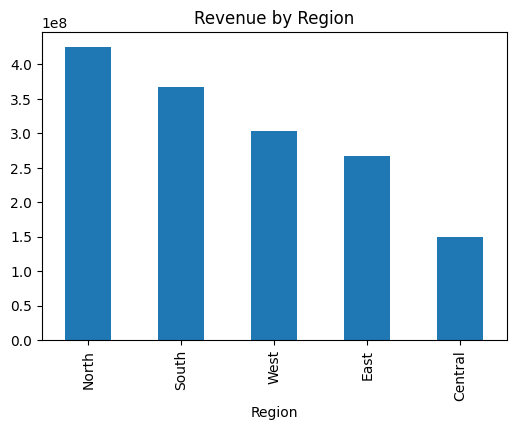

In [ ]:
df.groupby("Region")["NetRevenue"].sum().sort_values(ascending=False).plot(kind="bar", figsize=(6,4), title="Revenue by Region"); plt.show()

**Q9: Discount vs demand**

In [ ]:
df.groupby("Discount")["Quantity"].mean()

,Quantity
Discount,
0.00,4.094821
0.05,4.098004
0.10,4.389270
0.15,4.478474
0.20,4.570991


**Q10: Inventory risk flag (quick preview)**

In [ ]:
df["InventoryFlag"] = np.where(df["InventoryAtStart"] < df["ReorderPoint"], "Below Reorder Point", "OK")
df["InventoryFlag"].value_counts()

,count
InventoryFlag,
OK,86121
Below Reorder Point,5222


#4. PRODUCT LEVEL DEMAND ANALYSIS

Upload the clean dataset first

In [1]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_clean.csv to ecommerce_clean.csv


Load Clean Data

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("ecommerce_clean.csv", parse_dates=["OrderDate"])

Build a complete daily demand series per product

In [4]:
daily = df.groupby(["ProductID", "OrderDate"])["Quantity"].sum().reset_index()

full_dates = pd.date_range(df["OrderDate"].min(), df["OrderDate"].max(), freq="D")
products = df[["ProductID", "ProductName"]].drop_duplicates()

idx = pd.MultiIndex.from_product([products["ProductID"], full_dates], names=["ProductID", "OrderDate"])
daily_full = daily.set_index(["ProductID", "OrderDate"]).reindex(idx, fill_value=0).reset_index()

Core demand statistics per product

In [5]:
summary = daily_full.groupby("ProductID").agg(
    AvgDailyDemand=("Quantity", "mean"),
    StdDailyDemand=("Quantity", "std"),
).reset_index()

summary["AvgWeeklyDemand"] = summary["AvgDailyDemand"] * 7
summary["AvgMonthlyDemand"] = summary["AvgDailyDemand"] * 30
summary["CV"] = summary["StdDailyDemand"] / summary["AvgDailyDemand"]  # coefficient of variation

Demand trend (slope of monthly totals)

In [6]:
monthly = df.groupby(["ProductID", df["OrderDate"].dt.to_period("M")])["Quantity"].sum().reset_index()

def trend_slope(g):
    y = g["Quantity"].values
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0] if len(y) >= 2 else 0

trend = monthly.groupby("ProductID").apply(trend_slope).reset_index(name="Trend")
summary = summary.merge(trend, on="ProductID").merge(products, on="ProductID")

/tmp/ipykernel_6959/736501947.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = monthly.groupby("ProductID").apply(trend_slope).reset_index(name="Trend")


Classification

In [7]:
q_fast = summary["AvgDailyDemand"].quantile(0.66)
q_slow = summary["AvgDailyDemand"].quantile(0.33)

def classify(row):
    if row["CV"] > 1.0:
        return "Highly Volatile"
    if row["AvgDailyDemand"] >= q_fast:
        return "Fast-moving"
    if row["AvgDailyDemand"] <= q_slow:
        return "Slow-moving"
    return "Medium-moving"

summary["DemandClass"] = summary.apply(classify, axis=1)
summary["DemandClass"].value_counts()

,count
DemandClass,
Slow-moving,17
Fast-moving,17
Medium-moving,16


Save

In [9]:
summary.to_csv("product_demand_summary.csv", index=False)
summary.head()

,ProductID,AvgDailyDemand,StdDailyDemand,AvgWeeklyDemand,AvgMonthlyDemand,CV,Trend,ProductName,DemandClass
0,P1000,4.872263,3.406913,34.105839,146.167883,0.699246,-1.069143,ELE-AUD-1000,Slow-moving
1,P1001,11.047445,8.822728,77.332117,331.423358,0.798622,-4.617131,ELE-MOB-1001,Slow-moving
2,P1002,4.835766,3.306749,33.850365,145.072993,0.683811,-1.256966,ELE-WEA-1002,Slow-moving
3,P1003,11.671533,9.235580,81.700730,350.145985,0.791291,-2.753354,ELE-AUD-1003,Fast-moving
4,P1004,10.956204,7.897301,76.693431,328.686131,0.720806,-5.678019,ELE-MOB-1004,Slow-moving


In [10]:
from google.colab import files

files.download("product_demand_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#5. DEMAND FORECASTING

Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("ecommerce_clean.csv", parse_dates=["OrderDate"])

Select products to forecast

In [3]:
top_products = (
    df.groupby("ProductID")["NetRevenue"].sum()
    .sort_values(ascending=False).head(10).index.tolist()
)

full_dates = pd.date_range(df["OrderDate"].min(), df["OrderDate"].max(), freq="D")

def get_series(pid):
    daily = df[df["ProductID"] == pid].groupby("OrderDate")["Quantity"].sum()
    return daily.reindex(full_dates, fill_value=0)

Error metrics (MAPE ignores zero-demand days to avoid divide-by-zero)

In [4]:
def mape(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

def evaluate(actual, pred):
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    return mae, rmse, mape(actual, pred)

Backtest 3 approaches on a held-out 30-day window

In [5]:
horizon = 30
results = []

for pid in top_products:
    s = get_series(pid)
    train, test = s.iloc[:-horizon], s.iloc[-horizon:]

    naive_pred = np.repeat(train.iloc[-1], horizon)
    ma_pred = np.repeat(train.iloc[-7:].mean(), horizon)
    try:
        es_model = ExponentialSmoothing(train, trend=None, seasonal=None).fit()
        es_pred = es_model.forecast(horizon).values
    except Exception:
        es_pred = ma_pred

    for name, pred in [("Naive", naive_pred), ("MovingAvg7", ma_pred), ("ExpSmoothing", es_pred)]:
        mae, rmse, mp = evaluate(test.values, np.array(pred))
        results.append({"ProductID": pid, "Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mp})

backtest_df = pd.DataFrame(results)
backtest_df.groupby("Model")[["MAE", "RMSE", "MAPE"]].mean()

,MAE,RMSE,MAPE
Model,,,
ExpSmoothing,11.089380,13.841926,88.090967
MovingAvg7,11.179524,13.975995,86.087002
Naive,15.236667,17.864238,122.652160


Generate real 30-day forward forecast with the winning model

In [6]:
forecast_rows = []
for pid in top_products:
    s = get_series(pid)
    model = ExponentialSmoothing(s, trend=None, seasonal=None).fit()
    future_dates = pd.date_range(s.index.max() + pd.Timedelta(days=1), periods=horizon)
    preds = model.forecast(horizon)

    for d, p in zip(future_dates, preds):
        forecast_rows.append({
            "ProductID": pid, "ForecastDate": d, "ForecastDemand": max(0, round(p, 1)),
            "Model": "ExpSmoothing", "ActualDemand": np.nan
        })

forecast_df = pd.DataFrame(forecast_rows)

Attach backtest error metrics per product (for reference in Power BI/README)

In [7]:
best_metrics = backtest_df[backtest_df["Model"] == "ExpSmoothing"].set_index("ProductID")[["MAE","RMSE","MAPE"]]
forecast_df = forecast_df.merge(best_metrics, on="ProductID", how="left")
forecast_df.to_csv("product_forecast.csv", index=False)
forecast_df.head()

,ProductID,ForecastDate,ForecastDemand,Model,ActualDemand,MAE,RMSE,MAPE
0,P1045,2025-10-01,28.0,ExpSmoothing,NaN,17.827811,21.131291,109.327106
1,P1045,2025-10-02,28.0,ExpSmoothing,NaN,17.827811,21.131291,109.327106
2,P1045,2025-10-03,28.0,ExpSmoothing,NaN,17.827811,21.131291,109.327106
3,P1045,2025-10-04,28.0,ExpSmoothing,NaN,17.827811,21.131291,109.327106
4,P1045,2025-10-05,28.0,ExpSmoothing,NaN,17.827811,21.131291,109.327106


In [8]:
from google.colab import files

files.download("product_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Visualize historical vs forecast for 2–3 representative products

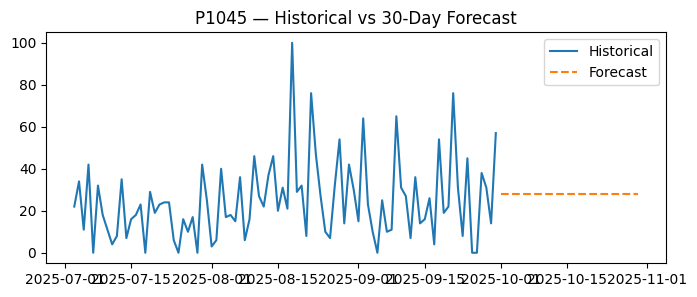

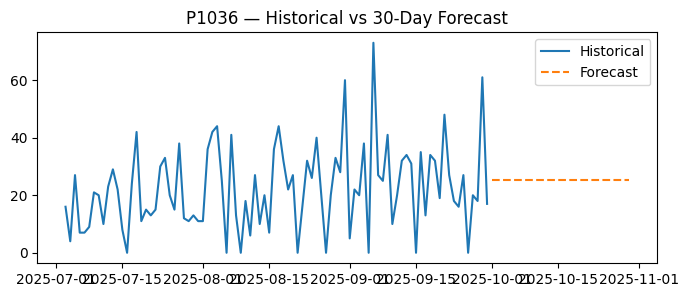

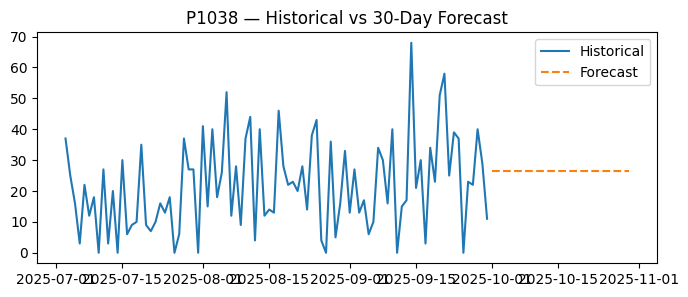

In [9]:
for pid in top_products[:3]:
    s = get_series(pid)
    sub_forecast = forecast_df[forecast_df["ProductID"] == pid]

    plt.figure(figsize=(8,3))
    plt.plot(s.index[-90:], s.values[-90:], label="Historical")
    plt.plot(pd.to_datetime(sub_forecast["ForecastDate"]), sub_forecast["ForecastDemand"], label="Forecast", linestyle="--")
    plt.title(f"{pid} — Historical vs 30-Day Forecast")
    plt.legend()
    plt.show()

#6. Inventory Risk Analysis

Load demand summary + latest inventory snapshot

In [11]:
from google.colab import files

uploaded = files.upload()

Saving product_demand_summary.csv to product_demand_summary.csv


In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("ecommerce_clean.csv", parse_dates=["OrderDate"])
demand_summary = pd.read_csv("product_demand_summary.csv")

# most recent known inventory level per product
latest = (
    df.sort_values("OrderDate")
    .groupby("ProductID").tail(1)[["ProductID", "InventoryAtStart", "ReorderPoint", "LeadTimeDays"]]
)

risk = demand_summary.merge(latest, on="ProductID")

Safety stock & reorder point

In [13]:
Z = 1.65

risk["SafetyStock"] = Z * risk["StdDailyDemand"] * np.sqrt(risk["LeadTimeDays"])
risk["ComputedReorderPoint"] = risk["AvgDailyDemand"] * risk["LeadTimeDays"] + risk["SafetyStock"]

Inventory coverage & risk flags

In [14]:
risk["InventoryCoverageDays"] = risk["InventoryAtStart"] / risk["AvgDailyDemand"]

risk["StockoutRisk"] = risk["InventoryAtStart"] < risk["ComputedReorderPoint"]
risk["ExcessInventoryRisk"] = risk["InventoryCoverageDays"] > 60   # more than ~2 months of stock on hand

Composite risk score/classification

In [15]:
def risk_score(row):
    score = 0
    if row["StockoutRisk"]:
        score += 2
    if row["DemandClass"] == "Highly Volatile":
        score += 1
    if row["ExcessInventoryRisk"]:
        score += 1
    if row["DemandClass"] == "Slow-moving" and row["ExcessInventoryRisk"]:
        score += 1

    if score >= 3:
        return "HIGH RISK"
    if score >= 1:
        return "MEDIUM RISK"
    return "LOW RISK"

risk["RiskLevel"] = risk.apply(risk_score, axis=1)
risk["RiskLevel"].value_counts()

,count
RiskLevel,
MEDIUM RISK,27
LOW RISK,23


Save

In [16]:
risk.to_csv("inventory_risk.csv", index=False)
risk.head()

,ProductID,AvgDailyDemand,StdDailyDemand,AvgWeeklyDemand,AvgMonthlyDemand,CV,Trend,ProductName,DemandClass,InventoryAtStart,ReorderPoint,LeadTimeDays,SafetyStock,ComputedReorderPoint,InventoryCoverageDays,StockoutRisk,ExcessInventoryRisk,RiskLevel
0,P1000,4.872263,3.406913,34.105839,146.167883,0.699246,-1.069143,ELE-AUD-1000,Slow-moving,70,65,18,23.849605,111.550335,14.367041,True,False,MEDIUM RISK
1,P1001,11.047445,8.822728,77.332117,331.423358,0.798622,-4.617131,ELE-MOB-1001,Slow-moving,116,35,20,65.103122,286.052027,10.500165,True,False,MEDIUM RISK
2,P1002,4.835766,3.306749,33.850365,145.072993,0.683811,-1.256966,ELE-WEA-1002,Slow-moving,206,19,5,12.200289,36.379122,42.599245,False,False,LOW RISK
3,P1003,11.671533,9.235580,81.700730,350.145985,0.791291,-2.753354,ELE-AUD-1003,Fast-moving,141,74,19,66.423982,288.183106,12.080675,True,False,MEDIUM RISK
4,P1004,10.956204,7.897301,76.693431,328.686131,0.720806,-5.678019,ELE-MOB-1004,Slow-moving,304,32,10,41.206207,150.768251,27.746835,False,False,LOW RISK
